# RESULTS ANALYSIS - DISPLACEMENT FEA ERROR
Uncomment the `FILE` for the model you want to use.
 
Be careful to only have one uncommented `FILE`.

In [2]:
# FILE = '../Data/FEA_results/Results for MLP_IG_23.06.2026.xlsx'
# FILE = '../Data/FEA_results/Results for MLP_FILTER_IG_23.06.2026.xlsx'
FILE = '../Data/FEA_results/Results for PINN_IG_24.06.2026.xlsx'
# FILE = '../Data/FEA_results/Results for PINN_FILTER_IG_24.06.2026.xlsx'

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.35})

MODEL_NAME = os.path.basename(FILE).replace('Results for ', '').replace('.xlsx', '')

COLS = ['Name', 'DeltaT', 'Beta', 'AnchorDisp', 'L', 'w',
        'FEA_Disp', 'FEA_Vol', 'FEA_Stress',
        '_', 'Target_Disp', 'Rel_Err', '_',
        'Pred_Stress', 'Pred_Vol', 'Stress_Err', 'Vol_Err', '_', '_']

df = pd.read_excel(FILE, sheet_name='1', header=None).iloc[7:].copy()
df.columns = COLS
df.drop(columns=['_'], inplace=True)
print(df.head())

num = ['DeltaT', 'Beta', 'L', 'w', 'FEA_Disp', 'Target_Disp', 'Rel_Err']
df[num] = df[num].apply(pd.to_numeric, errors='raise')
df = df.dropna(subset=['FEA_Disp', 'Target_Disp', 'Rel_Err']).reset_index(drop=True)

df['Beta_deg'] = df['Beta'] / 10.0
df['Abs_Err']  = df['Rel_Err'].abs()

n = len(df)
ae = df['Abs_Err']
print(f'Model  : {MODEL_NAME}')
print(f'Samples: {n}  (failed FEA runs excluded)')
print()
print(f'  Mean error    : {ae.mean():.3f} %')
print(f'  Median error  : {ae.median():.3f} %')
print(f'  Std error     : {ae.std():.3f} %')
print(f'  Max error     : {ae.max():.3f} %')
print()
print(f'  Within  1 %   :  {ae.le(1).sum():4d} / {n}  ({ae.le(1).mean()*100:.1f} %)')
print(f'  Within  5 %   :  {ae.le(5).sum():4d} / {n}  ({ae.le(5).mean()*100:.1f} %)')
print(f'  Within 10 %   :  {ae.le(10).sum():4d} / {n}  ({ae.le(10).mean()*100:.1f} %)')

    Name DeltaT   Beta AnchorDisp      L     w  FEA_Disp     FEA_Vol  \
7   DP 0   77.8    130   0.016288  24.44     1  0.071854  533.068292   
8   DP 1     73  114.4   0.017637  25.46     1  0.093255   531.72437   
9   DP 2   62.4  108.8   0.018915     35  1.23  0.113122  638.678044   
10  DP 3   75.5    130   0.014338  21.75     1  0.064377  516.928292   
11  DP 4   55.6    100    0.01485  31.06     1  0.146206  562.348987   

   FEA_Stress Target_Disp   Rel_Err Pred_Stress    Pred_Vol Stress_Err  \
7   73.793584    0.075367   4.88851   76.980843  522.374573   4.319154   
8   73.280737    0.090294 -3.175816   73.743378  529.366943   0.631326   
9   61.968301    0.114305  1.045284   63.061623  636.317505   1.764324   
10  73.184131    0.065959  2.457156   74.513657  502.226471   1.816686   
11  52.085862    0.133167 -8.918252   52.003738  561.071533  -0.157669   

     Vol_Err  
7  -2.006069  
8  -0.443355  
9  -0.369598  
10 -2.844074  
11 -0.227164  
Model  : PINN_IG_24.06.2026
Samp

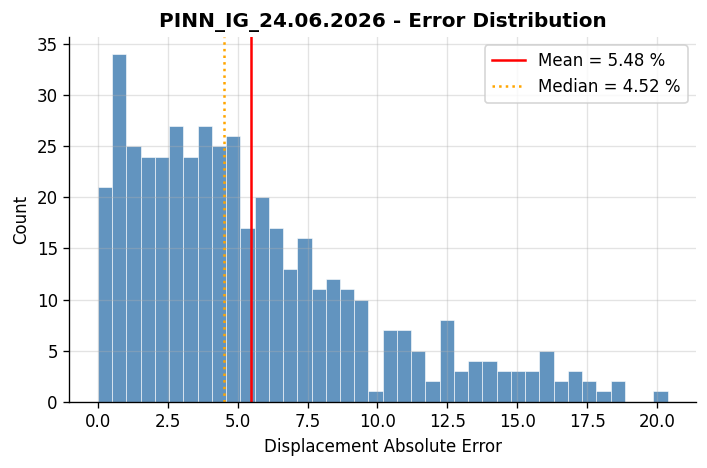

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(df['Abs_Err'], bins=40, color='steelblue', edgecolor='white', alpha=0.85, linewidth=0.4)
ax.axvline(df['Abs_Err'].mean(), color='red', lw=1.5, ls='-', label=f'Mean = {df["Abs_Err"].mean():.2f} %')
ax.axvline(df['Abs_Err'].median(), color='orange', lw=1.5, ls=':', label=f'Median = {df["Abs_Err"].median():.2f} %')
ax.set_xlabel('Displacement Absolute Error')
ax.set_ylabel('Count')
ax.set_title(f'{MODEL_NAME} - Error Distribution', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

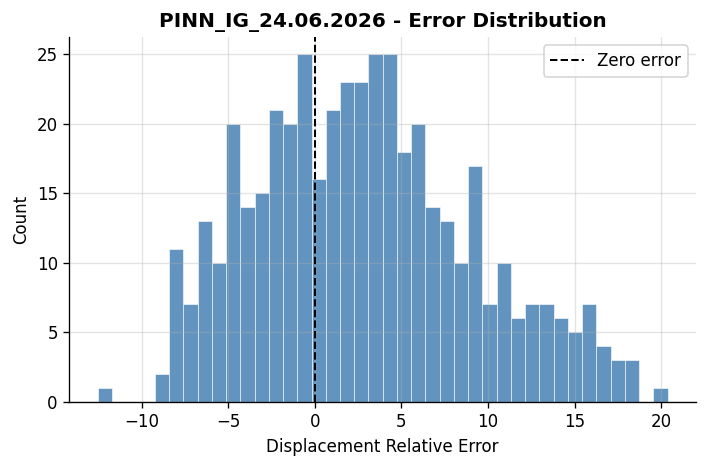

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(df['Rel_Err'], bins=40, color='steelblue', edgecolor='white', alpha=0.85, linewidth=0.4)
ax.axvline(0, color='black',  lw=1.2, ls='--', label='Zero error')
ax.set_xlabel('Displacement Relative Error')
ax.set_ylabel('Count')
ax.set_title(f'{MODEL_NAME} - Error Distribution', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

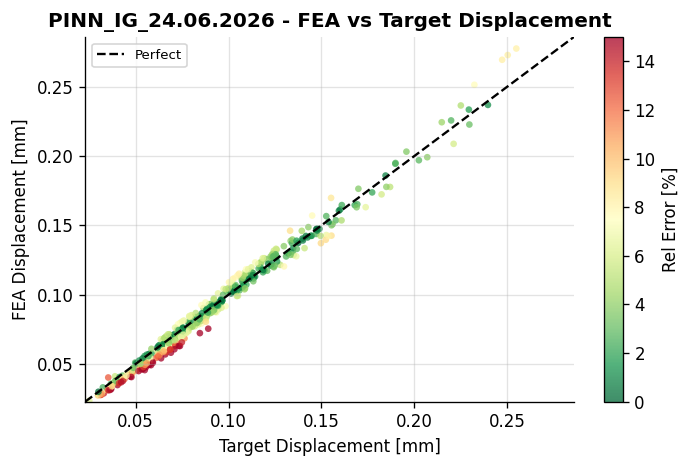

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))

sc = ax.scatter(df['Target_Disp'], df['FEA_Disp'],
                c=df['Abs_Err'], cmap='RdYlGn_r', vmin=0, vmax=15,
                s=16, alpha=0.75, edgecolors='none')
plt.colorbar(sc, ax=ax, label='Rel Error [%]')
lo = min(df['Target_Disp'].min(), df['FEA_Disp'].min()) * 0.97
hi = max(df['Target_Disp'].max(), df['FEA_Disp'].max()) * 1.03
ax.plot([lo, hi], [lo, hi], 'k--', lw=1.4, label='Perfect')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel('Target Displacement [mm]')
ax.set_ylabel('FEA Displacement [mm]')
ax.set_title(f'{MODEL_NAME} - FEA vs Target Displacement', fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

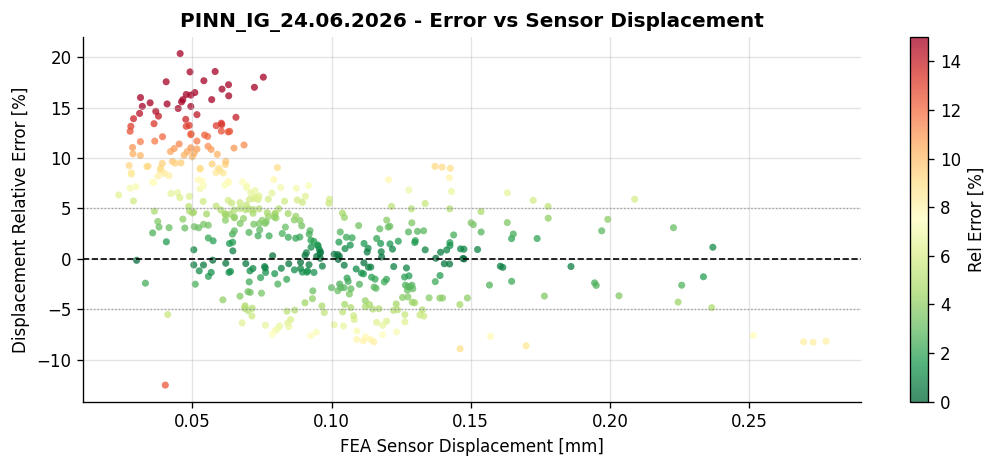

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
sc = ax.scatter(df['FEA_Disp'], df['Rel_Err'],
                c=df['Abs_Err'], cmap='RdYlGn_r', vmin=0, vmax=15,
                s=18, alpha=0.75, edgecolors='none')
plt.colorbar(sc, ax=ax, label='Rel Error [%]')
ax.axhline(0, color='black', lw=1, ls='--')
ax.axhline( 5, color='gray', lw=0.8, ls=':', alpha=0.7)
ax.axhline(-5, color='gray', lw=0.8, ls=':', alpha=0.7)
ax.set_xlabel('FEA Sensor Displacement [mm]')
ax.set_ylabel('Displacement Relative Error [%]')
ax.set_title(f'{MODEL_NAME} - Error vs Sensor Displacement', fontweight='bold')
plt.tight_layout()
plt.show()

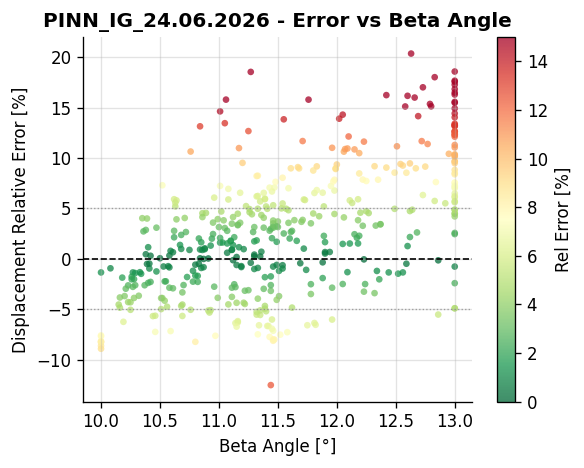

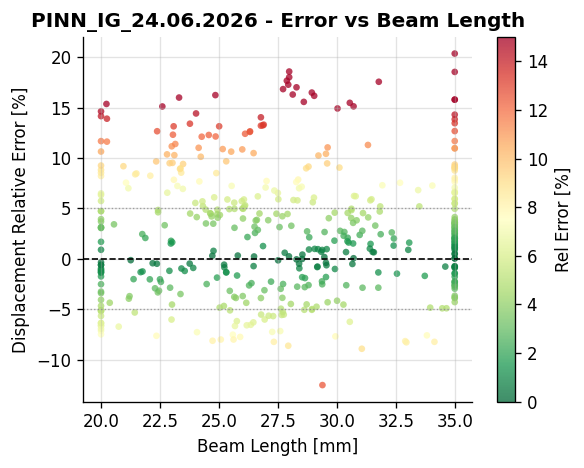

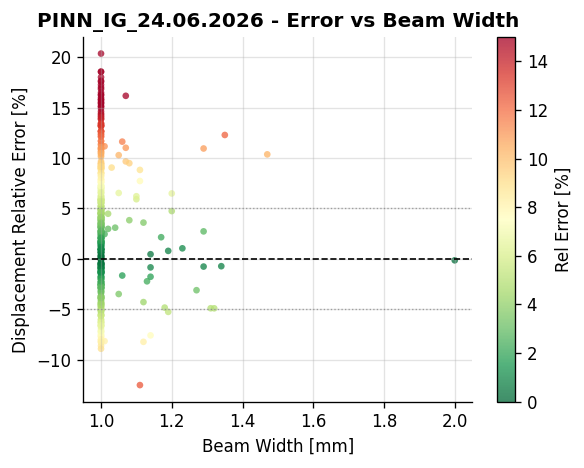

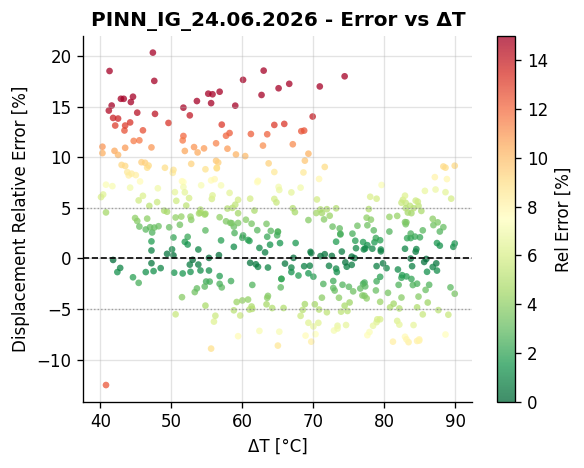

In [8]:
geom = [
    ('Beta_deg', 'Beta Angle [°]'),
    ('L', 'Beam Length [mm]'),
    ('w', 'Beam Width [mm]'),
    ('DeltaT', 'ΔT [°C]'),
]

for col, xlabel in geom:
    fig, ax = plt.subplots(figsize=(5, 4))

    sc = ax.scatter(df[col], df['Rel_Err'],
                    c=df['Abs_Err'], cmap='RdYlGn_r', vmin=0, vmax=15,
                    s=16, alpha=0.75, edgecolors='none')
    ax.axhline(0,  color='black', lw=1,   ls='--')
    ax.axhline( 5, color='gray',  lw=0.8, ls=':', alpha=0.7)
    ax.axhline(-5, color='gray',  lw=0.8, ls=':', alpha=0.7)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Displacement Relative Error [%]')
    ax.set_title(f'{MODEL_NAME} - Error vs {xlabel.split(" [")[0]}', fontweight='bold')
    fig.colorbar(sc, ax=ax, label='Rel Error [%]')

    plt.tight_layout()
    plt.show()